# PicoScope 3418E · ChipWhisperer-Lite · Husky 3중 파형 비교

이 노트북은 **하나의 STM32F303 암호 연산을 세 계측기가 동시에 본 결과가 얼마나
비슷한지** 사용자가 직접 확인하는 실험이다. Lite는 타겟 프로그래밍·UART·클럭 공급을
담당하고, Husky와 PicoScope 3418E는 같은 션트 및 트리거 신호를 수동 관측한다.

펌웨어는 단순 XOR 대신 다음 두 표준 알고리즘을 한 트랜잭션에서 실행한다.

1. **AES-128** — 키 확장, S-box, ShiftRows, MixColumns, AddRoundKey
2. **SHA-256** — 메시지 스케줄, 32비트 회전·시프트, 논리 함수, 모듈러 덧셈

PicoScope B의 첫 HIGH 펄스가 AES, 두 번째 HIGH 펄스가 SHA-256 구간이다. 이 디지털
파형을 구간 정본으로 삼으므로 아날로그 파형 모양을 보고 경계를 추측하지 않는다.

## 배선

| 신호 | 연결 |
|---|---|
| 션트/전력 | Lite 내장 측정 경로 + Husky Measure + PicoScope A |
| GPIO4/TRIG | Lite 내장 트리거 + Husky USERIO D0 + PicoScope B |
| 타겟 클럭 | Lite HS2 → CW308 CLKIN, 같은 신호를 Husky AUX MCX로 분기 |
| USB | Lite·Husky·PicoScope를 privileged Docker 컨테이너에 연결 |

PicoScope A는 50 Ω 동축 측정 경로를 종단하는 **DC 50 Ω**, B는 GPIO를 부하하지
않는 **DC 1 MΩ**이다. 3418E API에는 ChipWhisperer식 dB gain이 없으므로 그에
대응하는 Y축 감도는 A input range·analog offset·x1 probe scale로 최적화한다.
Lite·Husky gain은 비교 기준인 25 dB로 고정한다.

**Run All**은 의존성 준비, 펌웨어 빌드·플래싱, Pico 시간창 결정, 최종 sample
rate에서 10개 사전 파형과 10개 검증 파형으로 A range·analog offset 최적화,
고정 입력 5회, 무작위 입력 100회, 시각·통계 비교와 자원 해제를 모두 수행한다.
유사성에는 임의 합격선을 두지 않으며 연결·트리거·골든 모델·샘플 완전성만 실패로 판정한다.


## 1. 실행 환경 준비

기본 ChipWhisperer 커널에는 Pico Python 래퍼가 없으므로, 이 셀은 고정 버전
`pypicosdk`와 native `libpsospa`를 서브 프로젝트의 `.runtime/`에만 준비한다.
전역 Python 환경이나 Docker 이미지는 변경하지 않는다. 최초 실행에만 네트워크가 필요하며,
이후에는 같은 로컬 캐시를 재사용한다.


In [1]:
import importlib
import os
import shutil
import subprocess
import sys
import urllib.request
from pathlib import Path

PROJECT_DIR = Path('/workspace/[extra] PicoScope')
if not PROJECT_DIR.is_dir():
    raise RuntimeError('이 노트북은 chipwhisperer-kor Docker의 /workspace에서 실행해야 합니다.')

RUNTIME_DIR = PROJECT_DIR / '.runtime'
LOCAL_PYTHON_DIR = RUNTIME_DIR / 'python'
PICO_DRIVER_ROOT = RUNTIME_DIR / 'picoscope'
PICO_DRIVER_LIB = PICO_DRIVER_ROOT / 'lib' / 'libpsospa.so'
DOWNLOAD_DIR = RUNTIME_DIR / 'downloads'
RUNTIME_DIR.mkdir(exist_ok=True)

PYPICOSDK_VERSION = '1.7.5'
PICO_DRIVER_PACKAGE = 'libpsospa_1.1.7-0r5994_amd64.deb'
PICO_DRIVER_URL = (
    'https://labs.picotech.com/picoscope7/debian/pool/main/libp/libpsospa/'
    + PICO_DRIVER_PACKAGE
)

if not (LOCAL_PYTHON_DIR / 'pypicosdk').is_dir():
    print(f'[준비] pypicosdk {PYPICOSDK_VERSION} 로컬 설치')
    subprocess.run(
        [
            sys.executable, '-m', 'pip', 'install', '--no-deps', '--no-cache-dir',
            '--target', str(LOCAL_PYTHON_DIR), f'pypicosdk=={PYPICOSDK_VERSION}',
        ],
        check=True,
    )

sys.path.insert(0, str(LOCAL_PYTHON_DIR))
importlib.invalidate_caches()

if not PICO_DRIVER_LIB.exists():
    print(f'[준비] {PICO_DRIVER_PACKAGE} 로컬 추출')
    DOWNLOAD_DIR.mkdir(exist_ok=True)
    package_path = DOWNLOAD_DIR / PICO_DRIVER_PACKAGE
    if not package_path.exists():
        request = urllib.request.Request(
            PICO_DRIVER_URL, headers={'User-Agent': 'curl/8.0'}
        )
        with urllib.request.urlopen(request) as response, package_path.open('wb') as output:
            shutil.copyfileobj(response, output)

    extract_dir = RUNTIME_DIR / 'driver-extract'
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir()
    subprocess.run(['dpkg-deb', '-x', str(package_path), str(extract_dir)], check=True)
    source_root = extract_dir / 'opt' / 'picoscope'
    if not (source_root / 'lib').is_dir():
        raise RuntimeError(f'Pico driver 패키지 구조를 확인할 수 없습니다: {source_root}')
    if PICO_DRIVER_ROOT.exists():
        shutil.rmtree(PICO_DRIVER_ROOT)
    shutil.copytree(source_root, PICO_DRIVER_ROOT, symlinks=True)
    shutil.rmtree(extract_dir)

if not PICO_DRIVER_LIB.exists():
    raise RuntimeError(f'libpsospa 로딩 파일이 없습니다: {PICO_DRIVER_LIB}')

print('[✓] 노트북 전용 Pico 런타임 준비 완료')
print(f'    Python wrapper: {LOCAL_PYTHON_DIR}')
print(f'    Native driver: {PICO_DRIVER_LIB}')


[✓] 노트북 전용 Pico 런타임 준비 완료
    Python wrapper: /workspace/[extra] PicoScope/.runtime/python
    Native driver: /workspace/[extra] PicoScope/.runtime/picoscope/lib/libpsospa.so


## 2. 실험 설정과 분석 도구

다음 셀이 장비 시리얼, 수집 횟수, 입력 길이, Pico 트리거와 자동 캡처 정책의 단일
정의다. SHA-256 입력은 64바이트 메시지와 직전 AES 암호문 16바이트를 연결한
80바이트다. 호스트는 PyCryptodome AES와 Python `hashlib`로 48바이트 결과를 독립
계산한다.

긴 Pico 사전 캡처는 실제 실행 시간만 측정한다. 그 뒤 Lite 한도 안에 들어오는 가장 높은
Lite가 지원하는 ADC 배수(4× → 1×) 중 하나를 선택한다. 따라서 SHA 실행 시간이
예상보다 길어도 파형
뒷부분을 조용히 잘라내지 않는다. 최종 시간창에서 무작위 입력 10개를 측정한
global min/max와 3418E가 반환한 offset 한계로 수직축을 고르고, 같은 10개를
다시 측정해 양쪽 ADC rail의 10% 이상을 비웠을 때만 공식 수집을 시작한다.


In [2]:
import hashlib
import random
import time
import warnings

import chipwhisperer as cw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from Crypto.Cipher import AES
from IPython.display import display
from scipy import signal

import pypicosdk as psdk

psdk.override_directory(str(PICO_DRIVER_ROOT))

PLATFORM = 'CW308_STM32F3'
CRYPTO_TARGET = 'NONE'
SS_VER = 'SS_VER_2_1'
HUSKY_SERIAL_NUMBER = '502032204c5846303130313137313032'
LITE_SERIAL_NUMBER = '44203120394d36433130322030313035'

FIRMWARE_DIR = PROJECT_DIR / 'simpleserial_main'
FIRMWARE_PATH = FIRMWARE_DIR / f'simpleserial-scope-compare-{PLATFORM}.hex'
BUILD_OPTIONS = (
    f'PLATFORM={PLATFORM}', f'CRYPTO_TARGET={CRYPTO_TARGET}', f'SS_VER={SS_VER}'
)

AES_KEY_BYTES = 16
MESSAGE_BYTES = 64
RESULT_BYTES = 48
FIXED_CAPTURES = 5
RANDOM_CAPTURES = 100
RANDOM_SEED = 1

CW_GAIN_DB = 25
MAX_CW_SAMPLES = 24_000
MIN_CW_SAMPLES = 5_000
PRETRIGGER_PERCENT = 10
CAPTURE_POST_MARGIN_US = 50.0
ALIGNMENT_LIMIT_US = 2.0

# 3418E가 A/B 활성화와 약 7.4 MS/s에서 실제 허용하는 최고 분해능이다.
# 12-bit 이상은 driver가 PICO_RESOLUTION_NOT_SUPPORTED_BY_VARIANT로 거부한다.
PICO_RESOLUTION = '10bit'
# 현재 분기된 TRIG 선은 Pico 입력에서 약 0.33 V HIGH로 관측된다.
# ±1 V 범위의 150 mV 상승 에지는 잡음(약 ±0.12 V)을 피하면서 두 펄스를 잡는다.
PICO_TRIGGER_THRESHOLD_MV = 150
PICO_AUTO_TRIGGER_US = 1_000_000
PICO_LONG_RATE_SPS = 5_000_000
PICO_LONG_SAMPLES = 100_000
PICO_VERTICAL_PREFLIGHTS = 10
# 사전 측정에 없던 입력 변화가 본 수집에서 나타날 수 있으므로 각 ADC rail의
# 10%를 비워 둔다. 본 수집은 95%를 넘으면 설정 불일치로 즉시 중단한다.
PICO_VERTICAL_RAIL_LIMIT = 0.90
PICO_FORMAL_RAIL_LIMIT = 0.95
PICO_A_COUPLING = psdk.COUPLING.DC_50OHM
PICO_B_COUPLING = psdk.COUPLING.DC
PICO_B_RANGE = psdk.RANGE.V1
PICO_BANDWIDTH = psdk.BANDWIDTH_CH.BW_FULL
PICO_PROBE_SCALE = 1.0
PICO_A_RANGES = (
    (10, psdk.RANGE.mV10), (20, psdk.RANGE.mV20),
    (50, psdk.RANGE.mV50), (100, psdk.RANGE.mV100),
    (200, psdk.RANGE.mV200), (500, psdk.RANGE.mV500),
    (1_000, psdk.RANGE.V1), (2_000, psdk.RANGE.V2),
    (5_000, psdk.RANGE.V5),
)

FIXED_KEY = bytes(range(AES_KEY_BYTES))
FIXED_MESSAGE = bytes(range(MESSAGE_BYTES))

print('[✓] 설정 로드 완료')
print(f'    고정 입력 {FIXED_CAPTURES}회 + 무작위 입력 {RANDOM_CAPTURES}회')
print(f'    pypicosdk {getattr(psdk, "__version__", PYPICOSDK_VERSION)}')


/usr/local/lib/python3.12/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


[✓] 설정 로드 완료
    고정 입력 5회 + 무작위 입력 100회
    pypicosdk 1.7.5


In [3]:
def my_fsr_cmd(target, cmd, scmd, data, payload_only=False):
    '''SimpleSerial 2.1 명령을 보내고 500 ms 안에 첫 응답을 반환한다.

    송신 전 남은 ACK를 버린다. 응답이 없으면 TimeoutError, 프레임 길이가
    잘못되면 ValueError를 발생시키며 UART 버퍼와 타겟 명령 상태를 변경한다.
    '''
    target.flush()
    target.send_cmd(cmd=cmd, scmd=ord(scmd), data=data)
    response = target.read_cmd(timeout=500)
    if response is None:
        raise TimeoutError(f'SimpleSerial 응답 없음: 0x{cmd:02x}/{scmd}')
    if len(response) < 3:
        raise ValueError(f'SimpleSerial 응답 프레임이 너무 짧습니다: {response!r}')
    payload_end = 3 + response[2]
    if len(response) < payload_end:
        raise ValueError(f'SimpleSerial 응답 길이가 올바르지 않습니다: {response!r}')
    return bytes(response[3:payload_end]) if payload_only else response


def reset_target(scope, delay=0.05):
    '''Lite nRST로 타겟을 재시작하고 UART가 준비될 시간을 확보한다.'''
    scope.io.nrst = 'low'
    time.sleep(delay)
    scope.io.nrst = 'high_z'
    time.sleep(delay)


def golden_result(key, message):
    '''AES-128(message[:16]) || SHA-256(message || AES 결과)를 반환한다.'''
    ciphertext = AES.new(bytes(key), AES.MODE_ECB).encrypt(bytes(message[:16]))
    digest = hashlib.sha256(bytes(message) + ciphertext).digest()
    return ciphertext + digest


def run_target_transaction(target, key, message):
    '''입력을 저장하고 복합 연산을 실행해 검증된 48바이트 결과를 반환한다.'''
    if len(key) != AES_KEY_BYTES or len(message) != MESSAGE_BYTES:
        raise ValueError('키는 16바이트, 메시지는 64바이트여야 합니다.')
    if my_fsr_cmd(target, 0x81, 'k', key, True) != bytes(key):
        raise RuntimeError('타겟이 AES 키를 올바르게 되돌려주지 않았습니다.')
    if my_fsr_cmd(target, 0x81, 'm', message, True) != bytes(message):
        raise RuntimeError('타겟이 SHA 메시지를 올바르게 되돌려주지 않았습니다.')
    if my_fsr_cmd(target, 0x82, 'c', [], True) != b'\x01':
        raise RuntimeError('타겟 복합 연산 완료 응답이 올바르지 않습니다.')
    result = my_fsr_cmd(target, 0x83, 'r', [], True)
    expected = golden_result(key, message)
    if result != expected:
        raise RuntimeError(
            'AES·SHA 골든 모델 불일치\n'
            f'타겟: {result.hex()}\n골든: {expected.hex()}'
        )
    return result


def detect_trigger_pulses(time_us, trigger_mv, threshold_mv=PICO_TRIGGER_THRESHOLD_MV):
    '''Pico B에서 AES·SHA 두 HIGH 구간의 (시작, 끝) 시간을 반환한다.

    2 sample보다 짧은 교차는 잡음으로 버린다. 정확히 두 펄스가 아니면 구간
    해석이 불가능하므로 RuntimeError를 발생시킨다. 입력 배열은 변경하지 않는다.
    '''
    high = np.asarray(trigger_mv) >= threshold_mv
    edges = np.diff(high.astype(np.int8), prepend=0, append=0)
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    pulses = [(int(s), int(e)) for s, e in zip(starts, ends) if e - s >= 2]
    if len(pulses) != 2:
        raise RuntimeError(
            f'Pico B에서 유효한 트리거 펄스 2개가 필요하지만 {len(pulses)}개를 검출했습니다.'
        )
    return tuple((float(time_us[s]), float(time_us[min(e, len(time_us)-1)]))
                 for s, e in pulses)


def configure_pico_channels(pico, vertical):
    '''Pico A 측정과 B 상승 에지 트리거의 전체 front-end를 구성한다.

    vertical은 range enum, full scale과 analog offset을 담는다. A의 DC 50 Ω은
    케이블 종단인 동시에 측정 대상의 실제 부하이므로 자동 fallback하지 않는다.
    B는 GPIO trigger를 부하하지 않도록 DC 1 MΩ로 고정한다. SDK 설정 오류는
    그대로 전달하며 두 채널과 trigger 상태를 변경한다.
    '''
    pico.set_channel(
        channel=psdk.CHANNEL.A, range=vertical['range_enum'],
        coupling=PICO_A_COUPLING, offset=vertical['offset_v'],
        bandwidth=PICO_BANDWIDTH, probe_scale=PICO_PROBE_SCALE,
    )
    pico.set_channel(
        channel=psdk.CHANNEL.B, range=PICO_B_RANGE,
        coupling=PICO_B_COUPLING, offset=0.0,
        bandwidth=PICO_BANDWIDTH, probe_scale=PICO_PROBE_SCALE,
    )
    pico.set_simple_trigger(
        channel=psdk.CHANNEL.B,
        threshold=PICO_TRIGGER_THRESHOLD_MV,
        threshold_unit='mv',
        direction=psdk.TRIGGER_DIR.RISING,
        auto_trigger=PICO_AUTO_TRIGGER_US,
    )


def arm_pico(pico, sample_rate_sps, samples, pretrigger_percent):
    '''Pico 버퍼를 등록하고 비동기 블록 캡처를 시작한다.'''
    timebase = pico.sample_rate_to_timebase(
        sample_rate=sample_rate_sps, unit=psdk.SAMPLE_RATE.SPS
    )
    actual_rate = float(pico.get_actual_sample_rate())
    buffers = pico.set_data_buffer_for_enabled_channels(samples)
    pico.run_block_capture(timebase, samples, pretrigger_percent)
    return {
        'buffers': buffers, 'timebase': timebase, 'samples': samples,
        'pretrigger_percent': pretrigger_percent, 'sample_rate_sps': actual_rate,
    }


def read_pico(pico, armed, a_offset_v):
    '''완료를 기다린 뒤 A/B 파형과 시간축을 독립 배열로 반환한다.

    pypicosdk의 adc_to_mv는 analog offset을 복원하지 않는다. 따라서
    a_adc_window_mv는 ADC rail 판정용 값이고, a_mv는 SDK 정의대로 입력에
    더해진 offset을 빼서 복원한 물리 입력이다. 장비 버퍼를 읽어 소진한다.
    '''
    actual_samples = pico.get_values(armed['samples'])
    raw = {
        channel: np.asarray(buffer[:actual_samples]).copy()
        for channel, buffer in armed['buffers'].items()
    }
    converted = pico.adc_to_mv(raw)
    time_us = pico.get_time_axis(
        armed['timebase'], actual_samples,
        pre_trig_percent=armed['pretrigger_percent'], unit='us',
    )
    a_adc_window_mv = np.asarray(converted[psdk.CHANNEL.A], dtype=float)
    record = {
        'time_us': np.asarray(time_us, dtype=float),
        'a_adc_window_mv': a_adc_window_mv,
        'a_mv': a_adc_window_mv - float(a_offset_v) * 1_000.0,
        'b_mv': np.asarray(converted[psdk.CHANNEL.B], dtype=float),
        'sample_rate_sps': armed['sample_rate_sps'],
        'over_range_mask': int(getattr(pico, 'over_range', 0)),
    }
    return record


def get_pico_offset_limits(pico):
    '''3418E model JSON에서 X1·DC 50 Ω의 range별 offset 한계를 반환한다.

    반환값은 {full_scale_mv: (minimum_v, maximum_v)}다. 모델 정보가 없거나
    pypicosdk가 표현하는 범위와 일치하지 않으면 추측하지 않고 실패한다.
    장비 설정은 변경하지 않는다.
    '''
    details = pico.get_variant_details('3418E', buffer_size=131_072)
    limits = {}
    for full_scale_mv, _ in PICO_A_RANGES:
        expected_nv = int(full_scale_mv * 1_000_000)
        for setting in details['RangeSettings']:
            for probe in setting['ProbeSettings']:
                if (
                    int(probe['Type'])
                    != int(psdk.PICO_PROBE_RANGE_INFO.X1_PROBE_NV)
                    or int(probe['Max']) != expected_nv
                    or int(probe['Min']) != -expected_nv
                ):
                    continue
                match = next(
                    (item for item in probe['OffsetLimits']
                     if int(item['Coupling']) == int(PICO_A_COUPLING)),
                    None,
                )
                if match is not None:
                    limits[full_scale_mv] = (
                        float(match['Min']), float(match['Max'])
                    )
        if full_scale_mv not in limits:
            raise RuntimeError(
                f'3418E의 ±{full_scale_mv:g} mV·DC 50 Ω offset 한계가 없습니다.'
            )
    return limits


def choose_pico_vertical(records, offset_limits, minimum_full_scale_mv=0):
    '''전체 물리 min/max에 10% rail 여유를 주는 최소 range·offset을 고른다.

    각 후보에서 관측 envelope의 중심을 0 V로 옮기되 장비 offset 한계로
    clamp한다. 어떤 후보도 맞지 않으면 RuntimeError를 발생시키며 입력 기록과
    장비 상태는 변경하지 않는다.
    '''
    global_min_mv = min(float(np.min(record['a_mv'])) for record in records)
    global_max_mv = max(float(np.max(record['a_mv'])) for record in records)
    target_offset_v = -(global_min_mv + global_max_mv) / 2_000.0
    for full_scale_mv, range_enum in PICO_A_RANGES:
        if full_scale_mv < minimum_full_scale_mv:
            continue
        minimum_v, maximum_v = offset_limits[full_scale_mv]
        offset_v = float(np.clip(target_offset_v, minimum_v, maximum_v))
        centered = np.asarray(
            [global_min_mv, global_max_mv], dtype=float
        ) + offset_v * 1_000.0
        rail_fraction = float(np.max(np.abs(centered)) / full_scale_mv)
        if rail_fraction <= PICO_VERTICAL_RAIL_LIMIT:
            return {
                'range_enum': range_enum,
                'full_scale_mv': float(full_scale_mv),
                'offset_v': offset_v,
                'coupling': 'DC 50 Ω',
                'bandwidth': 'FULL',
                'probe_scale': PICO_PROBE_SCALE,
                'selection_min_mv': global_min_mv,
                'selection_max_mv': global_max_mv,
                'selection_rail_fraction': rail_fraction,
            }
    raise RuntimeError(
        'Pico A 사전 파형을 DC 50 Ω의 지원 range·offset 안에 넣을 수 없습니다: '
        f'{global_min_mv:.3f}–{global_max_mv:.3f} mV'
    )


def summarize_pico_vertical(records, vertical):
    '''10개 파형의 물리/ADC-window 수직 통계를 사용자 표시용으로 반환한다.'''
    trace_rows = []
    for index, record in enumerate(records):
        physical = record['a_mv']
        adc_window = record['a_adc_window_mv']
        trace_rows.append(
            {
                'trace': index + 1,
                'min_mv': float(np.min(physical)),
                'p0.1_mv': float(np.percentile(physical, 0.1)),
                'p99.9_mv': float(np.percentile(physical, 99.9)),
                'max_mv': float(np.max(physical)),
                'peak_to_peak_mv': float(np.ptp(physical)),
                'rail_fraction': float(
                    np.max(np.abs(adc_window)) / vertical['full_scale_mv']
                ),
                'over_range': int(record['over_range_mask'] != 0),
            }
        )
    per_trace = pd.DataFrame(trace_rows)
    global_min_mv = float(per_trace['min_mv'].min())
    global_max_mv = float(per_trace['max_mv'].max())
    peak_to_peak_mv = global_max_mv - global_min_mv
    utilization = peak_to_peak_mv / (2.0 * vertical['full_scale_mv'])
    rail_fraction = float(per_trace['rail_fraction'].max())
    resolution_bits = int(PICO_RESOLUTION.removesuffix('bit'))
    return {
        'per_trace': per_trace,
        'global_min_mv': global_min_mv,
        'global_max_mv': global_max_mv,
        'robust_min_mv': float(per_trace['p0.1_mv'].min()),
        'robust_max_mv': float(per_trace['p99.9_mv'].max()),
        'peak_to_peak_mv': peak_to_peak_mv,
        'utilization': utilization,
        'rail_fraction': rail_fraction,
        'headroom': 1.0 - rail_fraction,
        'effective_levels': utilization * (2 ** resolution_bits - 1),
        'over_range_count': int(per_trace['over_range'].sum()),
    }


def collect_pico_preflight(
    pico, target, inputs, sample_rate_sps, samples, vertical, label
):
    '''같은 설정으로 10개 전체-window 파형을 수집·검증해 반환한다.

    각 입력의 AES·SHA 결과와 B의 두 펄스를 확인한다. 파형은 최적화 그래프를
    위해 RAM에 남기며 장비 채널·버퍼와 타겟 상태를 변경한다.
    '''
    configure_pico_channels(pico, vertical)
    records = []
    for index, (key, message) in enumerate(inputs):
        armed = arm_pico(
            pico, sample_rate_sps, samples, PRETRIGGER_PERCENT
        )
        run_target_transaction(target, key, message)
        record = read_pico(pico, armed, vertical['offset_v'])
        record['pulses_us'] = detect_trigger_pulses(
            record['time_us'], record['b_mv']
        )
        records.append(record)
        print(f'    {label} {index + 1}/{len(inputs)}')
    return records


def make_inputs():
    '''사전 측정과 공식 수집이 공유할 결정적 입력 목록을 한 번 생성한다.'''
    rng = random.Random(RANDOM_SEED)
    random_inputs = []
    for _ in range(RANDOM_CAPTURES):
        key = bytes(rng.randrange(256) for _ in range(AES_KEY_BYTES))
        message = bytes(rng.randrange(256) for _ in range(MESSAGE_BYTES))
        random_inputs.append((key, message))
    return {
        'fixed': [(FIXED_KEY, FIXED_MESSAGE)] * FIXED_CAPTURES,
        'random': random_inputs,
    }


# +319 mV 위의 20 mV 신호는 offset 없이 ±500 mV가 필요하지만, 3418E의
# ±250 mV offset 한계를 적용하면 ±100 mV에 들어간다. 이 경계 사례로 선택과
# SDK offset 복원 부호를 하드웨어를 열기 전에 검증한다.
_synthetic_limits = {
    full_scale_mv: ((-0.25, 0.25) if full_scale_mv <= 200 else (-2.5, 2.5))
    for full_scale_mv, _ in PICO_A_RANGES
}
_synthetic_vertical = choose_pico_vertical(
    [{'a_mv': np.asarray([309.0, 329.0])}], _synthetic_limits
)
assert _synthetic_vertical['full_scale_mv'] == 100.0
assert _synthetic_vertical['offset_v'] == -0.25
assert float(69.0 - _synthetic_vertical['offset_v'] * 1_000.0) == 319.0
del _synthetic_limits, _synthetic_vertical


def choose_capture_geometry(target_clock_hz, operation_end_us):
    '''Lite 메모리에 들어오는 최고 ADC 배수와 sample/presample 수를 계산한다.'''
    post_window_us = operation_end_us + CAPTURE_POST_MARGIN_US
    total_window_us = post_window_us / (1.0 - PRETRIGGER_PERCENT / 100.0)
    for adc_mul in (4, 1):
        sample_rate = target_clock_hz * adc_mul
        samples = int(np.ceil(sample_rate * total_window_us * 1e-6 / 100.0) * 100)
        samples = max(samples, MIN_CW_SAMPLES)
        if samples <= MAX_CW_SAMPLES:
            presamples = int(round(samples * PRETRIGGER_PERCENT / 100.0))
            return adc_mul, samples, presamples
    raise RuntimeError(
        'AES·SHA 전체 구간이 Lite의 24,000 samples에 들어오지 않습니다. '
        '타겟 클럭 또는 펌웨어 실행 시간을 확인하세요.'
    )


## 3. 장비 연결·사전 측정·3중 수집

이 셀은 하드웨어를 여는 유일한 셀이다. 먼저 펌웨어를 clean build하여 Lite로
플래싱하고, Husky를 분기된 외부 클럭에 잠근다. Pico의 장시간 사전 캡처로 두
알고리즘의 실제 길이를 정한다. 이어서 공식 수집과 같은 시간축에서 Pico A의
DC 50 Ω·range·analog offset을 검증한 뒤 세 장비를 동시에 arm한다.

고정 입력 5회는 장비 자체의 반복 안정성에만 사용한다. 무작위 키·메시지 100회는
같은 물리 이벤트를 세 장비가 본 쌍별 유사성 분포에 사용한다. 어떤 단계에서든
실패하면 `finally`가 Pico, target, Husky, Lite와 빌드 산출물을 정리한다.


In [4]:
def run_hardware_experiment():
    '''전체 하드웨어 실험을 실행하고 연결이 모두 닫힌 결과 딕셔너리를 반환한다.'''
    lite_scope = None
    husky_scope = None
    target = None
    pico = None
    experiment = None

    try:
        print('=== 1/8 펌웨어 빌드 ===')
        subprocess.run(['make', *BUILD_OPTIONS, 'clean'], cwd=FIRMWARE_DIR, check=True)
        subprocess.run(['make', *BUILD_OPTIONS], cwd=FIRMWARE_DIR, check=True)
        if not FIRMWARE_PATH.is_file():
            raise RuntimeError(f'펌웨어 HEX가 생성되지 않았습니다: {FIRMWARE_PATH}')

        print('\n=== 2/8 세 계측기 연결 ===')
        lite_scope = cw.scope(sn=LITE_SERIAL_NUMBER)
        husky_scope = cw.scope(sn=HUSKY_SERIAL_NUMBER)

        pico = psdk.psospa()
        enumerated = pico.get_enumerated_units()
        pico_count = int(enumerated[0])
        pico_serials = str(enumerated[1]).split(',') if len(enumerated) >= 2 else []
        if pico_count != 1 or len([s for s in pico_serials if s]) != 1:
            raise RuntimeError(f'PicoScope 3418E 한 대만 연결해야 합니다: {enumerated!r}')
        pico_serial = pico_serials[0]
        pico.open_unit(serial_number=pico_serial, resolution=PICO_RESOLUTION)
        pico_variant = pico.get_unit_info(psdk.UNIT_INFO.PICO_VARIANT_INFO)
        if pico_variant != '3418E':
            raise RuntimeError(f'연결된 PicoScope가 3418E가 아닙니다: {pico_variant}')

        identity = pd.DataFrame(
            [
                ('ChipWhisperer-Lite', LITE_SERIAL_NUMBER, '통신·프로그래밍·측정'),
                ('ChipWhisperer-Husky', HUSKY_SERIAL_NUMBER, '수동 측정'),
                (f'PicoScope {pico_variant}', pico_serial, 'A=측정, B=트리거'),
            ],
            columns=['장비', '시리얼', '역할'],
        )
        display(identity)
        inputs = make_inputs()

        print('\n=== 3/8 타겟 프로그래밍과 골든 모델 점검 ===')
        lite_scope.default_setup()
        target = cw.target(lite_scope, cw.targets.SimpleSerial2)
        cw.program_target(
            lite_scope, cw.programmers.STM32FProgrammer, str(FIRMWARE_PATH)
        )
        reset_target(lite_scope)
        target.flush()
        fixed_expected = golden_result(FIXED_KEY, FIXED_MESSAGE)
        fixed_returned = run_target_transaction(target, FIXED_KEY, FIXED_MESSAGE)
        assert fixed_returned == fixed_expected
        print('[✓] AES-128·SHA-256 복합 결과 == 호스트 골든 모델')
        print(f'    AES : {fixed_returned[:16].hex()}')
        print(f'    SHA : {fixed_returned[16:].hex()}')

        print('\n=== 4/8 Husky 외부 클럭과 트리거 구성 ===')
        husky_scope.default_setup()
        time.sleep(0.5)
        husky_scope.clock.clkgen_freq = 0
        husky_scope.clock.reset_adc()
        husky_scope.io.aux_io_mcx = 'high_z'
        husky_scope.clock.clkgen_src = 'extclk_aux_io'
        husky_scope.clock.freq_ctr_src = 'extclk'
        husky_scope.clock.pll._allow_rdiv = True
        time.sleep(0.5)
        measured_freqs = np.asarray(
            [husky_scope.clock.freq_ctr for _ in range(20)], dtype=float
        )
        # Counter reads are already stable; short spacing prevents one stale USB read
        # from becoming the only frequency observation.
        for index in range(1, len(measured_freqs)):
            time.sleep(0.02)
            measured_freqs[index] = husky_scope.clock.freq_ctr
        values, counts = np.unique(measured_freqs.astype(np.int64), return_counts=True)
        target_clock_hz = float(values[np.argmax(counts)])
        husky_scope.clock.clkgen_freq = target_clock_hz
        husky_scope.trigger.triggers = 'userio_d0'
        husky_scope.trigger.module = 'basic'
        husky_scope.adc.basic_mode = 'rising_edge'
        husky_scope.clock.reset_adc()
        if not husky_scope.clock.adc_locked or not husky_scope.clock.clkgen_locked:
            raise RuntimeError('Husky 외부 클럭 PLL/ADC lock에 실패했습니다.')
        print(f'[✓] 외부 타겟 클럭 {target_clock_hz:,.0f} Hz, Husky PLL/ADC lock')

        print('\n=== 5/8 PicoScope 전체 시간창 사전 측정 ===')
        range_by_full_scale = dict(PICO_A_RANGES)
        broad_vertical = {
            'range_enum': range_by_full_scale[2_000],
            'full_scale_mv': 2_000.0,
            'offset_v': 0.0,
        }
        while True:
            configure_pico_channels(pico, broad_vertical)
            armed = arm_pico(
                pico, PICO_LONG_RATE_SPS, PICO_LONG_SAMPLES,
                PRETRIGGER_PERCENT,
            )
            run_target_transaction(target, FIXED_KEY, FIXED_MESSAGE)
            coarse_record = read_pico(pico, armed, 0.0)
            if coarse_record['over_range_mask'] == 0:
                break
            if broad_vertical['full_scale_mv'] >= 5_000:
                raise RuntimeError('Pico A가 DC 50 Ω·±5 V에서도 over-range입니다.')
            broad_vertical = {
                'range_enum': range_by_full_scale[5_000],
                'full_scale_mv': 5_000.0,
                'offset_v': 0.0,
            }
        coarse_record['pulses_us'] = detect_trigger_pulses(
            coarse_record['time_us'], coarse_record['b_mv']
        )
        aes_pulse, sha_pulse = coarse_record['pulses_us']
        if not (aes_pulse[0] < aes_pulse[1] < sha_pulse[0] < sha_pulse[1]):
            raise RuntimeError(f'AES·SHA 트리거 순서가 올바르지 않습니다: {calibration_record["pulses_us"]}')
        adc_mul, samples, presamples = choose_capture_geometry(
            target_clock_hz, sha_pulse[1]
        )
        print(f'[✓] AES 구간: {aes_pulse[1]-aes_pulse[0]:.2f} µs')
        print(f'[✓] SHA 구간: {sha_pulse[1]-sha_pulse[0]:.2f} µs')
        print(f'[✓] 공통 캡처: ADC {adc_mul}×, {samples:,} samples, {presamples:,} presamples')

        print('\n=== 6/8 Lite·Husky·Pico 공통 캡처 설정 ===')
        # ChipWhisperer 6.0.0 Lite의 adc_mul setter는 상태를 바꾸지 않으므로
        # Lite는 지원되는 adc_src를 직접 지정한다. Husky만 adc_mul을 사용한다.
        lite_scope.clock.adc_src = f'clkgen_x{adc_mul}'
        lite_scope.clock.reset_adc()
        husky_scope.clock.adc_mul = adc_mul
        husky_scope.clock.reset_adc()
        for scope in (lite_scope, husky_scope):
            scope.gain.db = CW_GAIN_DB
            scope.adc.samples = samples
            scope.adc.presamples = presamples
            scope.adc.offset = 0
            scope.adc.basic_mode = 'rising_edge'

        time.sleep(0.2)
        expected_adc_rate = target_clock_hz * adc_mul
        observed_adc_rates = {
            'Lite': float(lite_scope.clock.adc_freq),
            'Husky': float(husky_scope.clock.adc_freq),
        }
        for device, observed_rate in observed_adc_rates.items():
            relative_error = abs(observed_rate / expected_adc_rate - 1.0)
            if relative_error > 0.03:
                raise RuntimeError(
                    f'{device} ADC 속도가 {adc_mul}× 설정과 다릅니다: '
                    f'{observed_rate:,.0f} Hz (기대 {expected_adc_rate:,.0f} Hz)'
                )
        if not lite_scope.clock.adc_locked:
            raise RuntimeError('공통 ADC 배수 적용 후 Lite ADC lock에 실패했습니다.')
        if not husky_scope.clock.adc_locked or not husky_scope.clock.clkgen_locked:
            raise RuntimeError('공통 ADC 배수 적용 후 Husky PLL/ADC lock에 실패했습니다.')
        print(
            f"[✓] ADC 실측: Lite {observed_adc_rates['Lite']:,.0f} Hz, "
            f"Husky {observed_adc_rates['Husky']:,.0f} Hz"
        )

        requested_pico_rate = min(
            float(lite_scope.clock.adc_freq), float(husky_scope.clock.adc_freq)
        )

        print('\n=== 7/8 PicoScope A 수직축 10회 최적화·10회 검증 ===')
        offset_limits = get_pico_offset_limits(pico)
        preflight_inputs = inputs['random'][:PICO_VERTICAL_PREFLIGHTS]
        discovery_records = collect_pico_preflight(
            pico, target, preflight_inputs, requested_pico_rate, samples,
            broad_vertical, '사전 측정',
        )
        if any(record['over_range_mask'] != 0 for record in discovery_records):
            if broad_vertical['full_scale_mv'] >= 5_000:
                raise RuntimeError('Pico A가 DC 50 Ω·±5 V 사전 측정에서 over-range입니다.')
            broad_vertical = {
                'range_enum': range_by_full_scale[5_000],
                'full_scale_mv': 5_000.0,
                'offset_v': 0.0,
            }
            discovery_records = collect_pico_preflight(
                pico, target, preflight_inputs, requested_pico_rate, samples,
                broad_vertical, '±5 V 재측정',
            )
        discovery_summary = summarize_pico_vertical(
            discovery_records, broad_vertical
        )
        observations = list(discovery_records)
        minimum_full_scale_mv = 0
        while True:
            pico_vertical = choose_pico_vertical(
                observations, offset_limits, minimum_full_scale_mv
            )
            validation_records = collect_pico_preflight(
                pico, target, preflight_inputs, requested_pico_rate, samples,
                pico_vertical, '최적화 검증',
            )
            validation_summary = summarize_pico_vertical(
                validation_records, pico_vertical
            )
            if (
                validation_summary['over_range_count'] == 0
                and validation_summary['rail_fraction']
                <= PICO_VERTICAL_RAIL_LIMIT
            ):
                break
            observations.extend(validation_records)
            full_scales = [item[0] for item in PICO_A_RANGES]
            current = full_scales.index(pico_vertical['full_scale_mv'])
            if current + 1 >= len(full_scales):
                raise RuntimeError('Pico A 수직축을 ±5 V에서도 검증하지 못했습니다.')
            minimum_full_scale_mv = full_scales[current + 1]

        configure_pico_channels(pico, pico_vertical)
        calibration_record = validation_records[0]
        print(
            f'[✓] Pico A DC 50 Ω, ±{pico_vertical["full_scale_mv"]:g} mV, '
            f'analog offset {pico_vertical["offset_v"] * 1e3:+.3f} mV'
        )
        print(
            f'[✓] 검증 min/max '
            f'{validation_summary["global_min_mv"]:.3f} / '
            f'{validation_summary["global_max_mv"]:.3f} mV, '
            f'P-P 활용률 {validation_summary["utilization"]:.1%}, '
            f'최소 rail 여유 {validation_summary["headroom"]:.1%}'
        )

        def capture_triplet(key, message):
            armed_pico = arm_pico(
                pico, requested_pico_rate, samples, PRETRIGGER_PERCENT
            )
            husky_scope.arm()
            lite_scope.arm()
            result = run_target_transaction(target, key, message)
            husky_timeout = husky_scope.capture()
            lite_timeout = lite_scope.capture()
            pico_record = read_pico(
                pico, armed_pico, pico_vertical['offset_v']
            )
            pico_record['pulses_us'] = detect_trigger_pulses(
                pico_record['time_us'], pico_record['b_mv']
            )
            if husky_timeout or lite_timeout:
                raise RuntimeError(
                    f'ChipWhisperer timeout: Husky={husky_timeout}, Lite={lite_timeout}'
                )
            husky_wave = husky_scope.get_last_trace()
            lite_wave = lite_scope.get_last_trace()
            if husky_wave is None or len(husky_wave) != samples:
                raise RuntimeError('Husky Trace 길이가 설정값과 다릅니다.')
            if lite_wave is None or len(lite_wave) != samples:
                raise RuntimeError('Lite Trace 길이가 설정값과 다릅니다.')
            if len(pico_record['a_mv']) != samples:
                raise RuntimeError('PicoScope Trace 길이가 설정값과 다릅니다.')
            if pico_record['over_range_mask'] != 0:
                raise RuntimeError(
                    f'PicoScope over-range mask={pico_record["over_range_mask"]}'
                )
            rail_fraction = float(
                np.max(np.abs(pico_record['a_adc_window_mv']))
                / pico_vertical['full_scale_mv']
            )
            if rail_fraction > PICO_FORMAL_RAIL_LIMIT:
                raise RuntimeError(
                    f'PicoScope A rail 점유율이 본 수집 한계 95%를 넘었습니다: '
                    f'{rail_fraction:.1%}'
                )
            return {
                'lite': np.asarray(lite_wave, dtype=float),
                'husky': np.asarray(husky_wave, dtype=float),
                'pico_a': pico_record['a_mv'],
                'pico_b': pico_record['b_mv'],
                'pulses_us': pico_record['pulses_us'],
                'result': result,
                'pico_rate_sps': pico_record['sample_rate_sps'],
                'pico_rail_fraction': rail_fraction,
            }

        print('\n=== 8/8 고정 5회 + 무작위 100회 3중 수집 ===')
        fixed_records = []
        for index, (key, message) in enumerate(inputs['fixed']):
            fixed_records.append(capture_triplet(key, message))
            print(f'    고정 입력 {index + 1}/{FIXED_CAPTURES}')

        random_records = []
        input_keys = []
        input_messages = []
        for index, (key, message) in enumerate(inputs['random']):
            random_records.append(capture_triplet(key, message))
            input_keys.append(key)
            input_messages.append(message)
            if (index + 1) % 10 == 0:
                print(f'    무작위 입력 {index + 1}/{RANDOM_CAPTURES}')

        lite_rate = float(lite_scope.clock.adc_freq)
        husky_rate = float(husky_scope.clock.adc_freq)
        pico_rate = float(random_records[0]['pico_rate_sps'])
        lite_time_us = (np.arange(samples) - presamples) / lite_rate * 1e6
        husky_time_us = (np.arange(samples) - presamples) / husky_rate * 1e6
        pico_time_us = calibration_record['time_us']

        experiment = {
            'identity': identity,
            'fixed': fixed_records,
            'random': random_records,
            'keys': input_keys,
            'messages': input_messages,
            'calibration': calibration_record,
            'pico_vertical': pico_vertical,
            'vertical_preflight': {
                'discovery': discovery_records,
                'validation': validation_records,
                'discovery_summary': discovery_summary,
                'validation_summary': validation_summary,
            },
            'formal_max_rail_fraction': max(
                record['pico_rail_fraction']
                for record in fixed_records + random_records
            ),
            'adc_mul': adc_mul,
            'samples': samples,
            'presamples': presamples,
            'sample_rates': {
                'Lite': lite_rate, 'Husky': husky_rate, 'PicoScope': pico_rate,
            },
            'time_us': {
                'Lite': lite_time_us, 'Husky': husky_time_us,
                'PicoScope': pico_time_us,
            },
            'clock_measurements_hz': measured_freqs,
            'target_clock_hz': target_clock_hz,
        }
        print('\n[✓] 모든 하드웨어 캡처와 골든 모델 검증 완료')

    finally:
        print('\n장비와 빌드 자원 정리 중...')
        if pico is not None:
            try:
                pico.stop()
            except Exception:
                pass
            try:
                pico.close_unit()
                print('  [✓] PicoScope 연결 해제')
            except Exception as exc:
                print(f'  [!] PicoScope 해제 경고: {exc}')
        if target is not None:
            try:
                target.dis()
                print('  [✓] SimpleSerial target 연결 해제')
            except Exception as exc:
                print(f'  [!] target 해제 경고: {exc}')
        for name, scope in (('Husky', husky_scope), ('Lite', lite_scope)):
            if scope is not None:
                try:
                    scope.dis()
                    print(f'  [✓] {name} 연결 해제')
                except Exception as exc:
                    print(f'  [!] {name} 해제 경고: {exc}')
        clean = subprocess.run(
            ['make', *BUILD_OPTIONS, 'clean'], cwd=FIRMWARE_DIR,
            stdout=subprocess.DEVNULL, stderr=subprocess.PIPE, text=True,
        )
        if clean.returncode == 0:
            print('  [✓] 펌웨어 빌드 산출물 정리')
        else:
            print(f'  [!] 펌웨어 clean 경고: {clean.stderr.strip()}')

    if experiment is None:
        raise RuntimeError('실험 결과가 생성되지 않았습니다.')
    return experiment


EXPERIMENT = run_hardware_experiment()


=== 1/8 펌웨어 빌드 ===
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
Welcome to another exciting ChipWhisperer target build!!
.
Cleaning project:
rm -f -- simpleserial-scope-compare-CW308_CC2538.hex simpleserial-scope-compare-CW301_AVR.hex simpleserial-scope-compare-CW303.hex simpleserial-scope-compare-CW304.hex simpleserial-scope-compare-CW308_MEGARF.hex simpleserial-scope-compare-CW308_SAM4L.hex simpleserial-scope-compare-CW308_STM32F0.hex simpleserial-scope-compare-CW308_STM32F1.hex simpleserial-scope-compare-CW308_STM32F2.hex simpleserial-scope-compare-CW308_STM32F3.hex simpleserial-scope-compare-CW308_STM32F4.hex simpleserial-scope-compare-CW308_K24F.hex simpleserial-scope-compare-CW308_NRF52.hex simpleserial-scope-compare-CW308_AURIX.hex simpleserial-scope-compare-CW308_SAML11.hex simpleserial-scope-compare-CW308_EFM32TG11B.hex simpleserial-scope-compare-CWLITEARM.hex simpleserial-scope-compare-CWLITEXMEGA.hex simpleserial-scope-compare-CWNANO.hex simpleserial-scope-compare-CWH

,장비,시리얼,역할
0,ChipWhisperer-Lite,44203120394d36433130322030313035,통신·프로그래밍·측정
1,ChipWhisperer-Husky,502032204c5846303130313137313032,수동 측정
2,PicoScope 3418E,10561/0034,"A=측정, B=트리거"



=== 3/8 타겟 프로그래밍과 골든 모델 점검 ===
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 447435901                 to 459279415                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0   

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


[✓] 외부 타겟 클럭 7,384,494 Hz, Husky PLL/ADC lock

=== 5/8 PicoScope 전체 시간창 사전 측정 ===


(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:585) scope.clock.pll._allow_rdiv is True; this can cause an inconsistant phase relationship between the target and sampling clocks. Do you really want this?


[✓] AES 구간: 1114.02 µs
[✓] SHA 구간: 963.63 µs
[✓] 공통 캡처: ADC 1×, 17,800 samples, 1,780 presamples

=== 6/8 Lite·Husky·Pico 공통 캡처 설정 ===
[✓] ADC 실측: Lite 7,384,620 Hz, Husky 7,384,494 Hz

=== 7/8 PicoScope A 수직축 10회 최적화·10회 검증 ===
    사전 측정 1/10
    사전 측정 2/10
    사전 측정 3/10
    사전 측정 4/10
    사전 측정 5/10
    사전 측정 6/10
    사전 측정 7/10
    사전 측정 8/10
    사전 측정 9/10
    사전 측정 10/10
    최적화 검증 1/10
    최적화 검증 2/10
    최적화 검증 3/10
    최적화 검증 4/10
    최적화 검증 5/10
    최적화 검증 6/10
    최적화 검증 7/10
    최적화 검증 8/10
    최적화 검증 9/10
    최적화 검증 10/10
[✓] Pico A DC 50 Ω, ±20 mV, analog offset +1.957 mV
[✓] 검증 min/max -4.618 / 6.536 mV, P-P 활용률 27.9%, 최소 rail 여유 57.5%

=== 8/8 고정 5회 + 무작위 100회 3중 수집 ===
    고정 입력 1/5
    고정 입력 2/5
    고정 입력 3/5
    고정 입력 4/5
    고정 입력 5/5
    무작위 입력 10/100
    무작위 입력 20/100
    무작위 입력 30/100
    무작위 입력 40/100
    무작위 입력 50/100
    무작위 입력 60/100
    무작위 입력 70/100
    무작위 입력 80/100
    무작위 입력 90/100
    무작위 입력 100/100

[✓] 모든 하드웨어 캡처와 골든 모델 검증 완료

장비와 빌드 자원 정리 중...
  [✓] 

## 4. PicoScope 3418E 자체 점검 결과

아래 표와 그래프는 AI만 보는 단위 테스트가 아니라 실제 장비에서 방금 얻은 결과다.
A는 DC 50 Ω, B는 DC 1 MΩ임을 먼저 확인한다. 이어지는 10행 표와 before/after
그래프는 최종 sample rate에서 관측한 물리 min/max, 선택한 range·analog offset,
ADC rail 여유를 보여준다. B의 두 펄스, A의 수직축 검증과 over-range가 모두
통과해야 USB·driver·두 입력·블록 캡처·트리거 경로를 해석할 수 있다.


,점검,실측값,상태
0,PicoScope model,PicoScope 3418E,PASS
1,Pico resolution,10bit,PASS
2,Channel A coupling,DC 50 Ω,PASS
3,Channel B coupling,DC 1 MΩ,PASS
4,Channel A range,±20 mV,PASS
5,Channel A analog offset,+1.957 mV,PASS
6,Channel A bandwidth,FULL,PASS
7,10-trace physical min/max,-4.618 / 6.536 mV,PASS
8,10-trace robust 0.1/99.9%,-3.405 / 3.053 mV,PASS
9,Peak-to-peak range utilization,27.9%,PASS


,trace,min_mv,p0.1_mv,p99.9_mv,max_mv,peak_to_peak_mv,rail_fraction,over_range
0,1,-3.601,-3.366,2.935,3.327,6.928,26.4%,0
1,2,-3.679,-3.327,3.014,3.444,7.123,27.0%,0
2,3,-3.640,-3.405,3.053,5.010,8.650,34.8%,0
3,4,-3.679,-3.366,2.935,3.562,7.241,27.6%,0
4,5,-4.149,-3.327,3.014,3.483,7.632,27.2%,0
5,6,-3.757,-3.327,3.022,3.327,7.084,26.4%,0
6,7,-3.679,-3.327,2.982,3.288,6.967,26.2%,0
7,8,-3.640,-3.374,3.014,3.249,6.888,26.0%,0
8,9,-4.618,-3.366,3.053,6.536,11.155,42.5%,0
9,10,-3.836,-3.335,2.975,3.288,7.123,26.2%,0


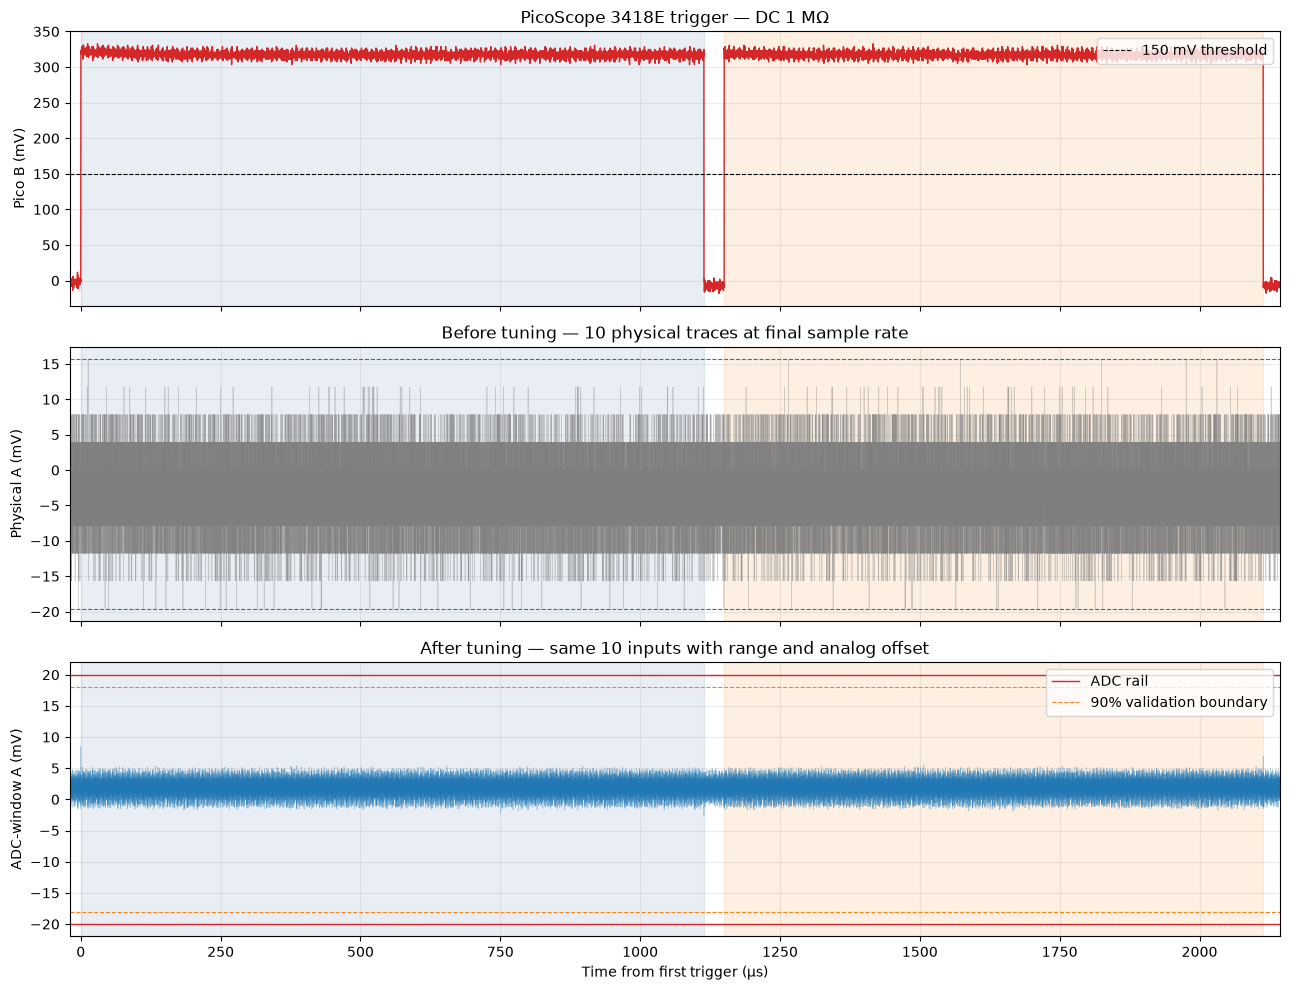

In [5]:
calibration = EXPERIMENT['calibration']
vertical = EXPERIMENT['pico_vertical']
preflight = EXPERIMENT['vertical_preflight']
validation_summary = preflight['validation_summary']
aes_cal, sha_cal = calibration['pulses_us']
status_table = pd.DataFrame(
    [
        ('PicoScope model', EXPERIMENT['identity'].iloc[2]['장비'], 'PASS'),
        ('Pico resolution', PICO_RESOLUTION, 'PASS'),
        ('Channel A coupling', 'DC 50 Ω', 'PASS'),
        ('Channel B coupling', 'DC 1 MΩ', 'PASS'),
        ('Channel A range', f"±{vertical['full_scale_mv']:g} mV", 'PASS'),
        ('Channel A analog offset', f"{vertical['offset_v'] * 1e3:+.3f} mV", 'PASS'),
        ('Channel A bandwidth', vertical['bandwidth'], 'PASS'),
        ('10-trace physical min/max',
         f"{validation_summary['global_min_mv']:.3f} / "
         f"{validation_summary['global_max_mv']:.3f} mV", 'PASS'),
        ('10-trace robust 0.1/99.9%',
         f"{validation_summary['robust_min_mv']:.3f} / "
         f"{validation_summary['robust_max_mv']:.3f} mV", 'PASS'),
        ('Peak-to-peak range utilization',
         f"{validation_summary['utilization']:.1%}", 'PASS'),
        ('Minimum ADC rail headroom',
         f"{validation_summary['headroom']:.1%}", 'PASS'),
        ('Estimated effective ADC levels',
         f"{validation_summary['effective_levels']:.1f}", 'PASS'),
        ('Preflight over-range',
         str(validation_summary['over_range_count']), 'PASS'),
        ('Formal maximum rail occupancy',
         f"{EXPERIMENT['formal_max_rail_fraction']:.1%}", 'PASS'),
        ('Channel B pulses', 'AES 1개 + SHA-256 1개', 'PASS'),
        ('Channel B min/max',
         f"{calibration['b_mv'].min():.1f} / {calibration['b_mv'].max():.1f} mV", 'PASS'),
        ('ADC geometry', f"{EXPERIMENT['adc_mul']}× / {EXPERIMENT['samples']:,} samples", 'PASS'),
    ],
    columns=['점검', '실측값', '상태'],
)
display(status_table)
display(
    validation_summary['per_trace'].style.format(
        {
            'min_mv': '{:.3f}', 'p0.1_mv': '{:.3f}',
            'p99.9_mv': '{:.3f}', 'max_mv': '{:.3f}',
            'peak_to_peak_mv': '{:.3f}', 'rail_fraction': '{:.1%}',
        }
    )
)

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
axes[0].plot(calibration['time_us'], calibration['b_mv'], color='#d62728', lw=1)
axes[0].axhline(PICO_TRIGGER_THRESHOLD_MV, color='black', ls='--', lw=0.8,
                label=f'{PICO_TRIGGER_THRESHOLD_MV:g} mV threshold')
axes[0].set_ylabel('Pico B (mV)')
axes[0].set_title('PicoScope 3418E trigger — DC 1 MΩ')
axes[0].legend(loc='upper right')
for record in preflight['discovery']:
    axes[1].plot(record['time_us'], record['a_mv'], color='#7f7f7f', alpha=0.35, lw=0.5)
axes[1].axhline(preflight['discovery_summary']['global_min_mv'], color='#1f77b4', ls='--', lw=0.8)
axes[1].axhline(preflight['discovery_summary']['global_max_mv'], color='#1f77b4', ls='--', lw=0.8)
axes[1].set_ylabel('Physical A (mV)')
axes[1].set_title('Before tuning — 10 physical traces at final sample rate')
for record in preflight['validation']:
    axes[2].plot(record['time_us'], record['a_adc_window_mv'], color='#1f77b4', alpha=0.35, lw=0.5)
for sign in (-1, 1):
    axes[2].axhline(sign * vertical['full_scale_mv'], color='#d62728', lw=1,
                    label='ADC rail' if sign > 0 else None)
    axes[2].axhline(sign * vertical['full_scale_mv'] * PICO_VERTICAL_RAIL_LIMIT,
                    color='#f58518', ls='--', lw=0.8,
                    label='90% validation boundary' if sign > 0 else None)
axes[2].set_ylabel('ADC-window A (mV)')
axes[2].set_xlabel('Time from first trigger (µs)')
axes[2].set_title('After tuning — same 10 inputs with range and analog offset')
axes[2].legend(loc='upper right')
for axis in axes:
    axis.axvspan(*aes_cal, color='#4c78a8', alpha=0.12)
    axis.axvspan(*sha_cal, color='#f58518', alpha=0.12)
    axis.grid(alpha=0.25)
    axis.set_xlim(aes_cal[0] - 20, sha_cal[1] + 30)
plt.tight_layout()
plt.show()


## 5. 같은 물리 이벤트의 세 파형을 병렬 확인

다음 그래프는 첫 무작위 입력 한 번을 네 줄로 나란히 표시한다. Pico B가 알고리즘
경계를 제공하고, Lite·Husky·Pico A는 각자 고유 단위를 유지한다. 절대 진폭은 ADC,
LNA gain과 입력 범위가 달라 직접 비교하지 않는다. 대신 같은 구간에서 특징점의 위치,
반복 구조, ringing과 noise floor를 육안으로 확인한다.


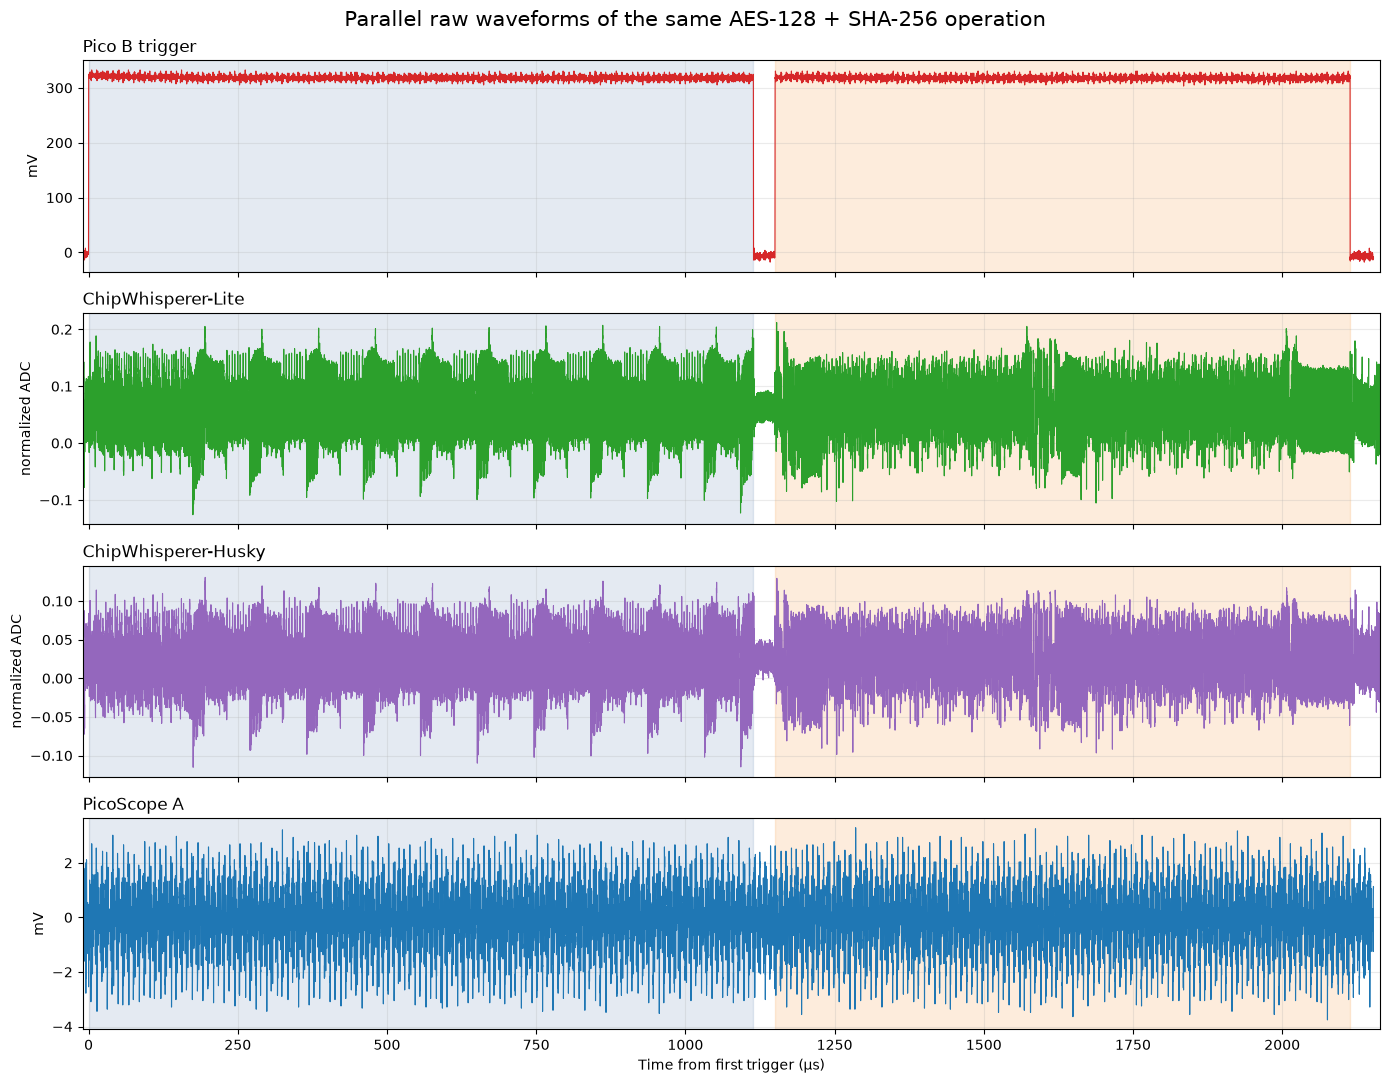

In [6]:
first = EXPERIMENT['random'][0]
first_aes, first_sha = first['pulses_us']
series = [
    ('Pico B trigger', EXPERIMENT['time_us']['PicoScope'], first['pico_b'], 'mV', '#d62728'),
    ('ChipWhisperer-Lite', EXPERIMENT['time_us']['Lite'], first['lite'], 'normalized ADC', '#2ca02c'),
    ('ChipWhisperer-Husky', EXPERIMENT['time_us']['Husky'], first['husky'], 'normalized ADC', '#9467bd'),
    ('PicoScope A', EXPERIMENT['time_us']['PicoScope'], first['pico_a'], 'mV', '#1f77b4'),
]
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for axis, (title, time_axis, values, unit, color) in zip(axes, series):
    axis.plot(time_axis, values, color=color, lw=0.8)
    axis.axvspan(*first_aes, color='#4c78a8', alpha=0.15)
    axis.axvspan(*first_sha, color='#f58518', alpha=0.15)
    axis.set_title(title, loc='left')
    axis.set_ylabel(unit)
    axis.grid(alpha=0.25)
axes[-1].set_xlabel('Time from first trigger (µs)')
axes[-1].set_xlim(first_aes[0] - 10, first_sha[1] + CAPTURE_POST_MARGIN_US)
fig.suptitle('Parallel raw waveforms of the same AES-128 + SHA-256 operation', fontsize=15)
plt.tight_layout()
plt.show()


## 6. 정량 비교

각 무작위 입력에서 Pico B가 표시한 AES, SHA-256, 전체 복합 구간을 공통 시간 격자로
보간한다. 각 장비 쌍은 ±2 µs 안에서 절대 교차상관이 가장 큰 지연을 찾는다.

- **|correlation|**: 1에 가까울수록 gain과 DC offset을 제외한 시간 파형 모양이 비슷하다.
- **polarity**: `same`은 같은 극성, `inverted`는 케이블·차동 경로 때문에 반전된 모양이다.
- **lag (ns)**: 두 번째 장비 파형의 상대 지연이다. 절댓값과 분산이 작을수록 정렬이 안정적이다.
- **spectral cosine**: 1에 가까울수록 시간 지연과 무관한 주파수 에너지 분포가 비슷하다.

이 값들은 계측 경로를 설명하는 수치이며 통과 기준이 아니다.


In [7]:
DEVICE_FIELDS = {
    'Lite': 'lite', 'Husky': 'husky', 'PicoScope': 'pico_a'
}
DEVICE_PAIRS = (
    ('Lite', 'Husky'), ('Lite', 'PicoScope'), ('Husky', 'PicoScope')
)


def stage_bounds(pulses):
    aes, sha = pulses
    return {'AES-128': aes, 'SHA-256': sha, 'Composite': (aes[0], sha[1])}


def common_window(record, device, bounds, sample_rate):
    start, end = bounds
    grid = np.arange(start, end, 1e6 / sample_rate)
    source_time = EXPERIMENT['time_us'][device]
    source = record[DEVICE_FIELDS[device]]
    return grid, np.interp(grid, source_time, source)


def aligned_similarity(x, y, sample_rate):
    '''최대 |Pearson r| 지연과 정렬 후 spectrum cosine을 반환한다.'''
    max_lag = max(1, int(round(ALIGNMENT_LIMIT_US * sample_rate / 1e6)))
    best = None
    for lag in range(-max_lag, max_lag + 1):
        if lag < 0:
            xa, ya = x[:lag], y[-lag:]
        elif lag > 0:
            xa, ya = x[lag:], y[:-lag]
        else:
            xa, ya = x, y
        if len(xa) < 8 or np.std(xa) == 0 or np.std(ya) == 0:
            continue
        correlation = float(np.corrcoef(xa, ya)[0, 1])
        candidate = (abs(correlation), correlation, lag, xa, ya)
        if best is None or candidate[0] > best[0]:
            best = candidate
    if best is None:
        raise RuntimeError('상관을 계산할 유효 파형 구간이 없습니다.')
    absolute, correlation, lag, xa, ya = best
    xa = (xa - np.mean(xa)) * np.hanning(len(xa))
    ya = (ya - np.mean(ya)) * np.hanning(len(ya))
    spectrum_x = np.abs(np.fft.rfft(xa))
    spectrum_y = np.abs(np.fft.rfft(ya))
    denominator = np.linalg.norm(spectrum_x) * np.linalg.norm(spectrum_y)
    spectral_cosine = float(np.dot(spectrum_x, spectrum_y) / denominator)
    return {
        'correlation': correlation,
        'abs_correlation': absolute,
        'polarity': 'same' if correlation >= 0 else 'inverted',
        'lag_ns': lag / sample_rate * 1e9,
        'spectral_cosine': spectral_cosine,
    }


common_rate = min(EXPERIMENT['sample_rates'].values())
metric_rows = []
native_rows = []
for trace_index, record in enumerate(EXPERIMENT['random']):
    windows = stage_bounds(record['pulses_us'])
    for stage, bounds in windows.items():
        waveforms = {}
        for device in DEVICE_FIELDS:
            _, waveforms[device] = common_window(record, device, bounds, common_rate)
            values = waveforms[device]
            if device == 'PicoScope':
                vertical = EXPERIMENT['pico_vertical']
                lower = -vertical['full_scale_mv'] - vertical['offset_v'] * 1e3
                upper = vertical['full_scale_mv'] - vertical['offset_v'] * 1e3
                margin = vertical['full_scale_mv'] * 0.01
                clipping = float(
                    np.mean((values <= lower + margin) | (values >= upper - margin))
                )
            else:
                clipping = float(np.mean(np.abs(values) >= 0.49))
            native_rows.append(
                {
                    'trace': trace_index, 'stage': stage, 'device': device,
                    'rms': float(np.sqrt(np.mean(values ** 2))),
                    'peak_to_peak': float(np.ptp(values)),
                    'clipping_fraction': clipping,
                }
            )
        for first_device, second_device in DEVICE_PAIRS:
            try:
                metrics = aligned_similarity(
                    waveforms[first_device], waveforms[second_device], common_rate
                )
            except RuntimeError as exc:
                first = waveforms[first_device]
                second = waveforms[second_device]
                raise RuntimeError(
                    f'trace={trace_index}, stage={stage}, '
                    f'pair={first_device}–{second_device}, bounds={bounds}, '
                    f'length={len(first)}, std=({np.std(first):.6g}, '
                    f'{np.std(second):.6g})'
                ) from exc
            metric_rows.append(
                {
                    'trace': trace_index, 'stage': stage,
                    'pair': f'{first_device} – {second_device}', **metrics,
                }
            )

METRICS = pd.DataFrame(metric_rows)
NATIVE_STATS = pd.DataFrame(native_rows)

metric_summary = (
    METRICS.groupby(['stage', 'pair'], sort=False)
    .agg(
        abs_corr_median=('abs_correlation', 'median'),
        abs_corr_iqr=('abs_correlation', lambda s: s.quantile(.75)-s.quantile(.25)),
        lag_median_ns=('lag_ns', 'median'),
        lag_iqr_ns=('lag_ns', lambda s: s.quantile(.75)-s.quantile(.25)),
        lag_std_ns=('lag_ns', 'std'),
        spectral_median=('spectral_cosine', 'median'),
        inverted_count=('polarity', lambda s: int((s == 'inverted').sum())),
    )
    .reset_index()
)
display(metric_summary.round(4))


,stage,pair,abs_corr_median,abs_corr_iqr,lag_median_ns,lag_iqr_ns,lag_std_ns,spectral_median,inverted_count
0,AES-128,Lite – Husky,0.9857,0.0004,-406.2567,0.0000,0.0000,0.9912,0
1,AES-128,Lite – PicoScope,0.0327,0.0117,406.2567,1625.0267,1188.8500,0.3032,47
2,AES-128,Husky – PicoScope,0.0340,0.0103,406.2567,1895.8645,1199.8870,0.3075,48
3,SHA-256,Lite – Husky,0.9667,0.0006,-406.2567,0.0000,0.0000,0.9866,0
4,SHA-256,Lite – PicoScope,0.0363,0.0140,541.6756,1354.1889,1053.7918,0.5087,46
5,SHA-256,Husky – PicoScope,0.0370,0.0146,812.5134,1895.8645,1192.0748,0.5260,47
6,Composite,Lite – Husky,0.9768,0.0003,-406.2567,0.0000,0.0000,0.9887,0
7,Composite,Lite – PicoScope,0.0281,0.0084,541.6756,1218.7700,961.1581,0.4703,37
8,Composite,Husky – PicoScope,0.0272,0.0095,880.2228,1218.7700,944.4466,0.4680,42


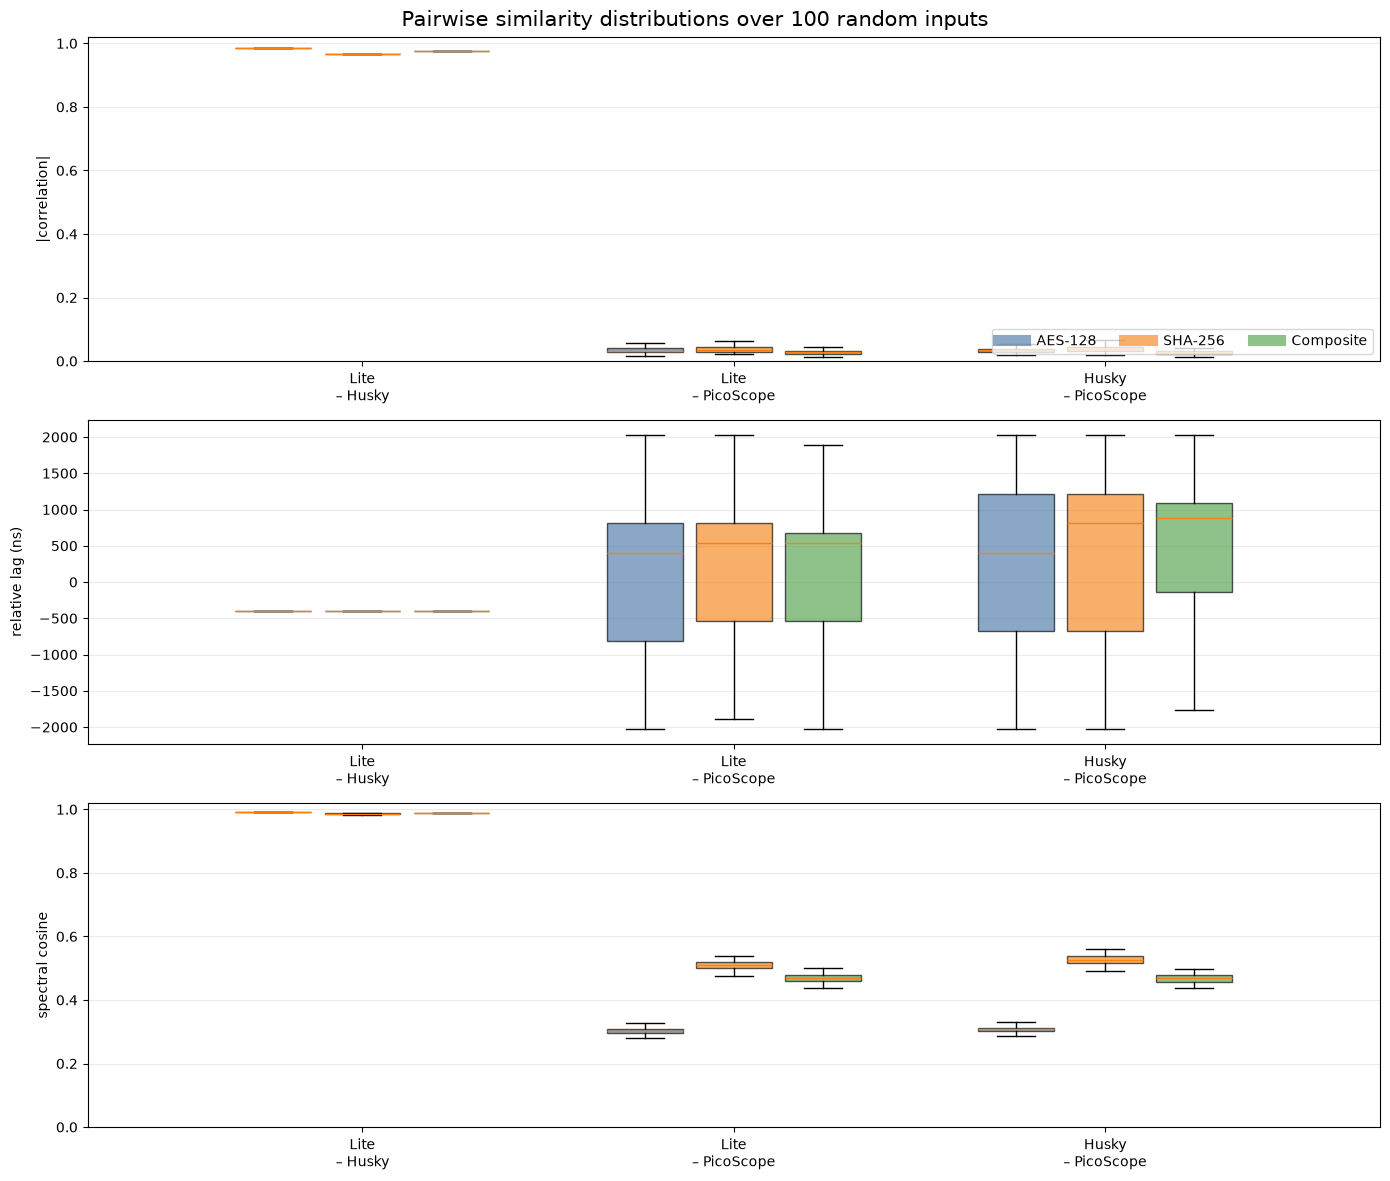

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
metric_specs = [
    ('abs_correlation', '|correlation|', (0, 1.02)),
    ('lag_ns', 'relative lag (ns)', None),
    ('spectral_cosine', 'spectral cosine', (0, 1.02)),
]
positions = np.arange(len(DEVICE_PAIRS))
width = 0.24
stage_order = ['AES-128', 'SHA-256', 'Composite']
colors = ['#4c78a8', '#f58518', '#54a24b']
for axis, (column, label, ylim) in zip(axes, metric_specs):
    for stage_index, (stage, color) in enumerate(zip(stage_order, colors)):
        values = [
            METRICS[(METRICS.stage == stage) &
                    (METRICS.pair == f'{a} – {b}')][column].to_numpy()
            for a, b in DEVICE_PAIRS
        ]
        box = axis.boxplot(
            values, positions=positions + (stage_index - 1) * width,
            widths=width * 0.85, patch_artist=True, showfliers=False,
        )
        for patch in box['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.65)
    axis.set_ylabel(label)
    axis.set_xticks(positions)
    axis.set_xticklabels([f'{a}\n– {b}' for a, b in DEVICE_PAIRS])
    axis.grid(axis='y', alpha=0.25)
    if ylim:
        axis.set_ylim(*ylim)
axes[0].legend(
    [plt.Line2D([0], [0], color=color, lw=8, alpha=.65) for color in colors],
    stage_order, loc='lower right', ncol=3,
)
fig.suptitle('Pairwise similarity distributions over 100 random inputs', fontsize=15)
plt.tight_layout()
plt.show()


## 7. 정규화 평균 파형과 반복 안정성

다음 그림은 무작위 입력 100개의 trigger-relative 평균을 장비별로 z-score 정규화한
것이다. gain 차이를 제거한 뒤 AES와 SHA 구간의 거시 구조를 비교한다. 표의 반복
상관은 **동일한 고정 입력 5회만** 사용하므로 입력 의존 누설과 계측 반복 오차를 섞지
않는다. Pico B 펄스 시작 시간의 표준편차는 전체 실험의 트리거 지터를 나타낸다.


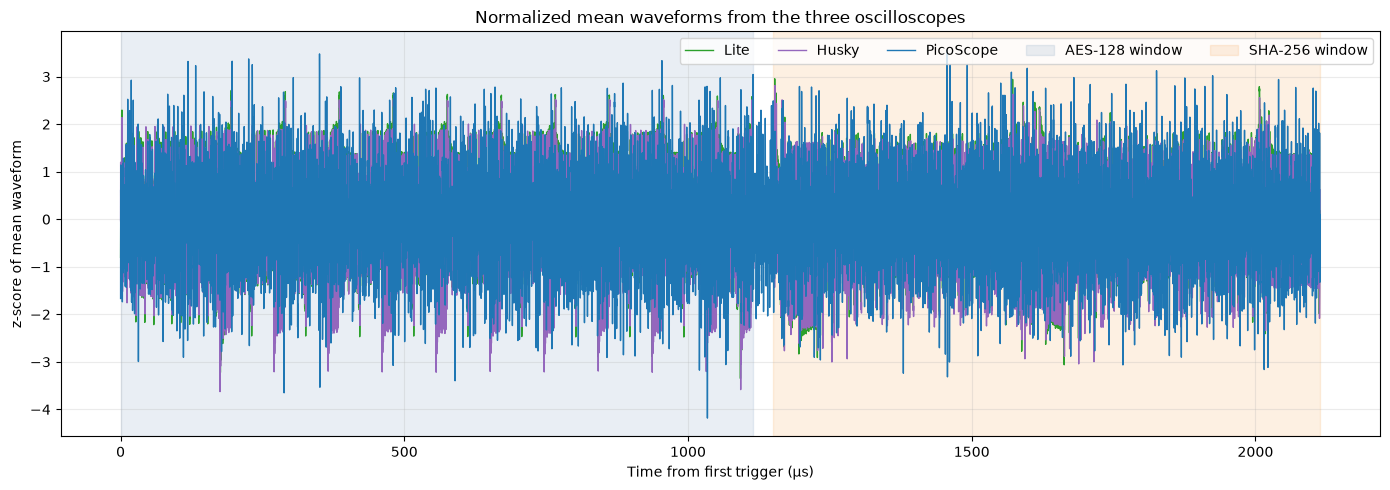

,device,stage,fixed_repeat_corr_median,fixed_repeat_corr_min
0,Lite,AES-128,0.9993,0.9992
1,Lite,SHA-256,0.9992,0.9991
2,Lite,Composite,0.9992,0.9992
3,Husky,AES-128,0.9963,0.9852
4,Husky,SHA-256,0.9972,0.9809
5,Husky,Composite,0.9964,0.9841
6,PicoScope,AES-128,0.4917,0.2502
7,PicoScope,SHA-256,0.4683,0.2569
8,PicoScope,Composite,0.4866,0.2531


,Pico B edge,jitter std (ns)
0,AES rising,0.000
1,AES falling,65.842
2,SHA rising,65.842
3,SHA falling,53.760


In [9]:
median_pulses = np.median(
    np.asarray([record['pulses_us'] for record in EXPERIMENT['random']]), axis=0
)
plot_start = float(median_pulses[0, 0])
plot_end = float(median_pulses[1, 1])
plot_grid = np.arange(plot_start, plot_end, 1e6 / common_rate)

plt.figure(figsize=(14, 5))
for device, color in zip(DEVICE_FIELDS, ['#2ca02c', '#9467bd', '#1f77b4']):
    traces = []
    for record in EXPERIMENT['random']:
        traces.append(np.interp(
            plot_grid, EXPERIMENT['time_us'][device], record[DEVICE_FIELDS[device]]
        ))
    mean_trace = np.mean(np.asarray(traces), axis=0)
    normalized = (mean_trace - mean_trace.mean()) / mean_trace.std()
    plt.plot(plot_grid, normalized, lw=1.0, label=device, color=color)
plt.axvspan(*median_pulses[0], color='#4c78a8', alpha=.12, label='AES-128 window')
plt.axvspan(*median_pulses[1], color='#f58518', alpha=.12, label='SHA-256 window')
plt.xlabel('Time from first trigger (µs)')
plt.ylabel('z-score of mean waveform')
plt.title('Normalized mean waveforms from the three oscilloscopes')
plt.grid(alpha=.25)
plt.legend(ncol=5, loc='upper right')
plt.tight_layout()
plt.show()

repeatability_rows = []
fixed_pulses = np.asarray([record['pulses_us'] for record in EXPERIMENT['fixed']])
fixed_windows = {
    'AES-128': tuple(np.median(fixed_pulses[:, 0, :], axis=0)),
    'SHA-256': tuple(np.median(fixed_pulses[:, 1, :], axis=0)),
    'Composite': (
        float(np.median(fixed_pulses[:, 0, 0])),
        float(np.median(fixed_pulses[:, 1, 1])),
    ),
}
for device in DEVICE_FIELDS:
    for stage, bounds in fixed_windows.items():
        stage_traces = [
            common_window(record, device, bounds, common_rate)[1]
            for record in EXPERIMENT['fixed']
        ]
        median_trace = np.median(np.asarray(stage_traces), axis=0)
        correlations = [
            abs(float(np.corrcoef(trace, median_trace)[0, 1]))
            for trace in stage_traces
        ]
        repeatability_rows.append(
            {
                'device': device, 'stage': stage,
                'fixed_repeat_corr_median': float(np.median(correlations)),
                'fixed_repeat_corr_min': float(np.min(correlations)),
            }
        )
REPEATABILITY = pd.DataFrame(repeatability_rows)
trigger_jitter = pd.DataFrame(
    [
        ('AES rising', np.std(fixed_pulses[:, 0, 0]) * 1e3),
        ('AES falling', np.std(fixed_pulses[:, 0, 1]) * 1e3),
        ('SHA rising', np.std(fixed_pulses[:, 1, 0]) * 1e3),
        ('SHA falling', np.std(fixed_pulses[:, 1, 1]) * 1e3),
    ],
    columns=['Pico B edge', 'jitter std (ns)'],
)
display(REPEATABILITY.round(4))
display(trigger_jitter.round(3))


In [10]:
native_summary = (
    NATIVE_STATS.groupby(['stage', 'device'], sort=False)
    .agg(
        rms_median=('rms', 'median'),
        peak_to_peak_median=('peak_to_peak', 'median'),
        clipping_max=('clipping_fraction', 'max'),
    )
    .reset_index()
)
display(native_summary.round(6))

if len(EXPERIMENT['fixed']) != FIXED_CAPTURES:
    raise RuntimeError('고정 입력 캡처 수가 목표와 다릅니다.')
if len(EXPERIMENT['random']) != RANDOM_CAPTURES:
    raise RuntimeError('무작위 입력 캡처 수가 목표와 다릅니다.')
if (NATIVE_STATS['clipping_fraction'] > 0).any():
    warnings.warn('하나 이상의 분석 구간에서 ADC clipping sample이 검출됐습니다.')

print('=== Run All 최종 결과 ===')
print(f"[✓] 고정 입력 3중 캡처: {len(EXPERIMENT['fixed'])}/{FIXED_CAPTURES}")
print(f"[✓] 무작위 입력 3중 캡처: {len(EXPERIMENT['random'])}/{RANDOM_CAPTURES}")
print('[✓] 모든 타겟 결과가 AES-128·SHA-256 골든 모델과 일치')
print('[✓] Pico B의 AES·SHA 두 펄스로 모든 분석 구간 확인')
print('[✓] 장비 연결은 수집 셀의 finally에서 모두 해제됨')
print('\n유사성 표는 합격 판정이 아니라 세 측정 경로의 차이를 정량화한 결과입니다.')


,stage,device,rms_median,peak_to_peak_median,clipping_max
0,AES-128,Lite,0.080469,0.308437,0.0
1,AES-128,Husky,0.045154,0.236125,0.0
2,AES-128,PicoScope,1.114983,6.542957,0.0
3,SHA-256,Lite,0.081118,0.309530,0.0
4,SHA-256,Husky,0.042043,0.215367,0.0
5,SHA-256,PicoScope,1.116712,6.528712,0.0
6,Composite,Lite,0.079403,0.319826,0.0
7,Composite,Husky,0.044390,0.240613,0.0
8,Composite,PicoScope,1.115329,6.765605,0.0


=== Run All 최종 결과 ===
[✓] 고정 입력 3중 캡처: 5/5
[✓] 무작위 입력 3중 캡처: 100/100
[✓] 모든 타겟 결과가 AES-128·SHA-256 골든 모델과 일치
[✓] Pico B의 AES·SHA 두 펄스로 모든 분석 구간 확인
[✓] 장비 연결은 수집 셀의 finally에서 모두 해제됨

유사성 표는 합격 판정이 아니라 세 측정 경로의 차이를 정량화한 결과입니다.


## 해석 요약

- 병렬 원시 그래프에서 세 측정 파형의 특징점 순서와 반복 구조를 먼저 본다.
- Pico A의 DC 50 Ω 종단과 analog offset은 실제 입력 회로·ADC 좌표를 바꾼다.
  사전/검증 표에서 10개 전체의 min/max, P-P 활용률, rail 여유를 먼저 확인한다.
- `|correlation|`과 spectral cosine이 함께 높으면 진폭·극성 차이를 제외한 모양과
  주파수 구성이 모두 비슷하다.
- correlation은 높은데 lag 분산이 크면 아날로그 품질보다 trigger/clock 정렬을 먼저
  점검한다.
- AES만 낮고 SHA는 높거나 그 반대라면 특정 주파수·연산 길이에 대한 계측 경로 차이가
  드러난 것이다.
- Pico B 두 펄스, clipping, 골든 모델 중 하나라도 실패한 실행의 유사성 수치는 해석하지
  않는다.

이 노트북은 첫 단계인 **계측 경로 동일성 비교**까지만 수행한다. 저장 Dataset,
CPA/DPA와 공격 성공 여부는 별도의 실험 목표와 판정 기준을 고정한 뒤 진행해야 한다.
